# Sistema masa–resorte–amortiguador: solución numérica de una EDO de segundo orden
**Métodos Computacionales en Ingeniería (MCEI_M)** – Escuela Colombiana de Ingeniería Julio Garavito
**Autor:** Carlos Castillo

## Problema
El movimiento de un sistema acoplado masa–resorte está descrito por

$$m\,\frac{d^2x}{dt^2} + c\,\frac{dx}{dt} + k\,x = 0,$$

con $m = 20$ kg, $k = 20$ N/m, $x(0) = 1$ m y $\dot x(0) = 0$. Se resuelve numéricamente para $0 < t < 15$ s con tres coeficientes de amortiguamiento:
$c = 5$ (subamortiguado), $c = 40$ (crítico) y $c = 200$ (sobreamortiguado) N·s/m, y se grafican los tres desplazamientos en la misma figura.

## 1. Planteamiento como sistema de primer orden
Los métodos numéricos para EDO (Euler, Runge–Kutta) trabajan con sistemas de primer orden. Definiendo el vector de estado $\mathbf{y} = [y_1,\ y_2]^T = [x,\ \dot x]^T$:

$$\frac{d\mathbf{y}}{dt} = \mathbf{f}(t,\mathbf{y}) = \begin{bmatrix} y_2 \\[2pt] -\dfrac{c}{m}\,y_2 - \dfrac{k}{m}\,y_1 \end{bmatrix}, \qquad \mathbf{y}(0) = \begin{bmatrix} 1 \\ 0 \end{bmatrix}.$$

**Parámetros adimensionales.** Frecuencia natural $\omega_n = \sqrt{k/m} = 1$ rad/s, amortiguamiento crítico $c_c = 2\sqrt{mk} = 40$ N·s/m y razón de amortiguamiento $\zeta = c/c_c$:

| $c$ (N·s/m) | $\zeta$ | Régimen |
|---|---|---|
| 5 | 0.125 | Subamortiguado ($\zeta<1$) |
| 40 | 1 | Crítico ($\zeta=1$) |
| 200 | 5 | Sobreamortiguado ($\zeta>1$) |

Esto confirma que los tres valores del enunciado corresponden a los tres regímenes.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros del sistema
m, k = 20.0, 20.0                       # kg, N/m
x0, v0 = 1.0, 0.0                       # m, m/s
t0, tf = 0.0, 15.0                      # s
casos = {5.0: "Subamortiguado", 40.0: "Crítico", 200.0: "Sobreamortiguado"}

wn = np.sqrt(k / m)
c_crit = 2.0 * np.sqrt(m * k)
print(f"ω_n = {wn:.3f} rad/s,  c_crítico = {c_crit:.1f} N·s/m")
for c, nombre in casos.items():
    print(f"c = {c:5.0f} N·s/m  →  ζ = {c/c_crit:.3f}  ({nombre})")

ω_n = 1.000 rad/s,  c_crítico = 40.0 N·s/m
c =     5 N·s/m  →  ζ = 0.125  (Subamortiguado)
c =    40 N·s/m  →  ζ = 1.000  (Crítico)
c =   200 N·s/m  →  ζ = 5.000  (Sobreamortiguado)


## 2. Método numérico: Runge–Kutta clásico de 4.º orden (RK4)
Para un paso $h$:

$$\begin{aligned}
\mathbf{k}_1 &= \mathbf{f}(t_n,\ \mathbf{y}_n) \\
\mathbf{k}_2 &= \mathbf{f}(t_n + \tfrac{h}{2},\ \mathbf{y}_n + \tfrac{h}{2}\mathbf{k}_1) \\
\mathbf{k}_3 &= \mathbf{f}(t_n + \tfrac{h}{2},\ \mathbf{y}_n + \tfrac{h}{2}\mathbf{k}_2) \\
\mathbf{k}_4 &= \mathbf{f}(t_n + h,\ \mathbf{y}_n + h\,\mathbf{k}_3) \\
\mathbf{y}_{n+1} &= \mathbf{y}_n + \tfrac{h}{6}\,(\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4)
\end{aligned}$$

El error global es $O(h^4)$. Se implementa de forma vectorial para que sirva con cualquier sistema de primer orden.

In [2]:
def f_masa_resorte(t, y, c):
    # Lado derecho del sistema de primer orden: y = [x, v]
    x, v = y
    return np.array([v, -(c / m) * v - (k / m) * x])


def rk4(f, t_span, y0, h, args=()):
    # Runge-Kutta clásico de 4.º orden con paso fijo h
    t0, tf = t_span
    n = int(round((tf - t0) / h))
    t = np.linspace(t0, tf, n + 1)
    h = (tf - t0) / n                    # paso efectivo, consistente con la malla
    y = np.zeros((n + 1, len(y0)))
    y[0] = y0
    for i in range(n):
        k1 = f(t[i],         y[i],                 *args)
        k2 = f(t[i] + h / 2, y[i] + h / 2 * k1,    *args)
        k3 = f(t[i] + h / 2, y[i] + h / 2 * k2,    *args)
        k4 = f(t[i] + h,     y[i] + h * k3,        *args)
        y[i + 1] = y[i] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return t, y

## 3. Solución analítica (para validar)
Con $\omega_n = 1$, $x(0)=1$ y $\dot x(0)=0$, la solución exacta depende del régimen:

- **Subamortiguado** ($\zeta<1$), con $\omega_d = \omega_n\sqrt{1-\zeta^2}$:
$\quad x(t) = e^{-\zeta\omega_n t}\left[\cos\omega_d t + \dfrac{\zeta\omega_n}{\omega_d}\sin\omega_d t\right]$
- **Crítico** ($\zeta=1$): $\quad x(t) = (1 + \omega_n t)\,e^{-\omega_n t}$
- **Sobreamortiguado** ($\zeta>1$), con raíces $r_{1,2} = \omega_n\left(-\zeta \pm \sqrt{\zeta^2-1}\right)$:
$\quad x(t) = \dfrac{r_2\,e^{r_1 t} - r_1\,e^{r_2 t}}{r_2 - r_1}$

In [3]:
def x_exacta(t, c):
    z = c / c_crit
    if np.isclose(z, 1.0):
        return (1 + wn * t) * np.exp(-wn * t)
    if z < 1.0:
        wd = wn * np.sqrt(1 - z**2)
        return np.exp(-z * wn * t) * (np.cos(wd * t) + (z * wn / wd) * np.sin(wd * t))
    r1 = wn * (-z + np.sqrt(z**2 - 1))
    r2 = wn * (-z - np.sqrt(z**2 - 1))
    return (r2 * np.exp(r1 * t) - r1 * np.exp(r2 * t)) / (r2 - r1)

## 4. Solución numérica para los tres casos
Paso $h = 0.01$ s (1500 pasos). Para el caso sobreamortiguado la raíz más rápida es $r_2 \approx -9.9$ s$^{-1}$; RK4 es estable si $|r_2|\,h \lesssim 2.78$, es decir $h \lesssim 0.28$ s, así que $h=0.01$ s está muy por dentro de la región de estabilidad. Se compara además con `solve_ivp` de SciPy (RK45 adaptativo).

In [4]:
h = 0.01
y0 = np.array([x0, v0])
resultados = {}

print(f"{'c':>5} {'régimen':<17} {'err máx RK4':>12} {'err máx RK45':>13} {'t RK4 (ms)':>11} {'evals RK45':>11}")
for c, nombre in casos.items():
    t_ini = time.perf_counter()
    t, Y = rk4(f_masa_resorte, (t0, tf), y0, h, args=(c,))
    t_rk4 = (time.perf_counter() - t_ini) * 1e3

    sol = solve_ivp(f_masa_resorte, (t0, tf), y0, args=(c,), method="RK45",
                    t_eval=t, rtol=1e-8, atol=1e-10)

    x_ex = x_exacta(t, c)
    err_rk4 = np.max(np.abs(Y[:, 0] - x_ex))
    err_scipy = np.max(np.abs(sol.y[0] - x_ex))
    resultados[c] = dict(t=t, x=Y[:, 0], v=Y[:, 1], x_ex=x_ex, nombre=nombre)
    print(f"{c:5.0f} {nombre:<17} {err_rk4:12.2e} {err_scipy:13.2e} {t_rk4:11.1f} {sol.nfev:11d}")

    c régimen            err máx RK4  err máx RK45  t RK4 (ms)  evals RK45
    5 Subamortiguado        2.47e-10      4.31e-09        28.7        1112
   40 Crítico               9.70e-11      6.30e-10        13.5         656
  200 Sobreamortiguado      3.30e-09      1.23e-10        13.5         602


## 5. Gráfica: desplazamiento vs. tiempo para los tres coeficientes

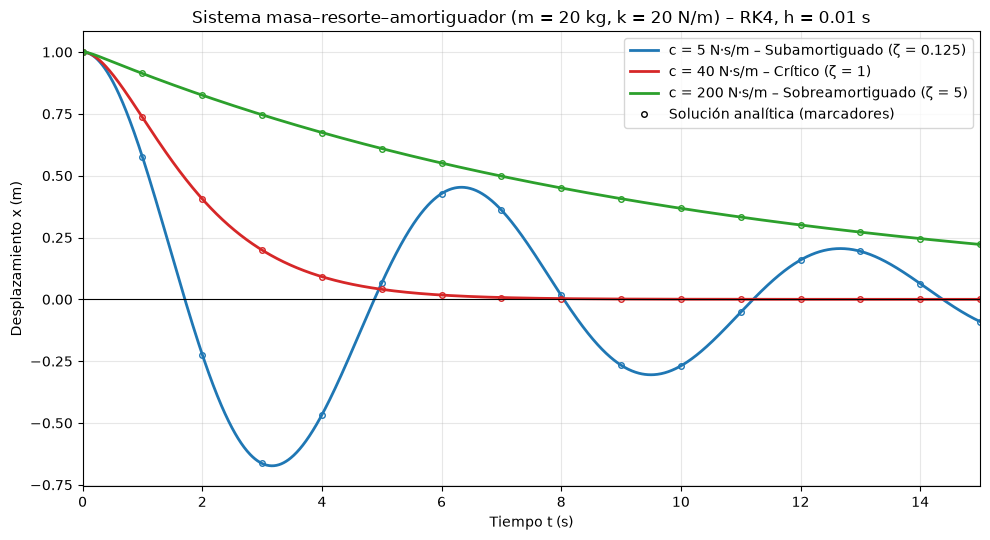

In [5]:
colores = {5.0: "#1f77b4", 40.0: "#d62728", 200.0: "#2ca02c"}

fig, ax = plt.subplots(figsize=(10, 5.5))
for c, r in resultados.items():
    ax.plot(r["t"], r["x"], color=colores[c], lw=2,
            label=f"c = {c:.0f} N·s/m – {r['nombre']} (ζ = {c/c_crit:.3g})")
    ax.plot(r["t"][::100], r["x_ex"][::100], "o", color=colores[c], ms=4, mfc="none")
ax.plot([], [], "ko", mfc="none", ms=4, label="Solución analítica (marcadores)")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="Tiempo t (s)", ylabel="Desplazamiento x (m)", xlim=(t0, tf),
       title="Sistema masa–resorte–amortiguador (m = 20 kg, k = 20 N/m) – RK4, h = 0.01 s")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("masa_resorte_desplazamiento.png", dpi=150)
plt.show()

## 6. Verificación del orden de convergencia de RK4
Si el método es de orden 4, al dividir $h$ por 2 el error debe dividirse por $2^4 = 16$. Se verifica con el caso subamortiguado.

  h (s)   error máx   razón  orden p
  0.400   6.173e-04
  0.200   4.031e-05   15.31     3.94
  0.100   2.492e-06   16.17     4.02
  0.050   1.549e-07   16.09     4.01
  0.025   9.655e-09   16.04     4.00


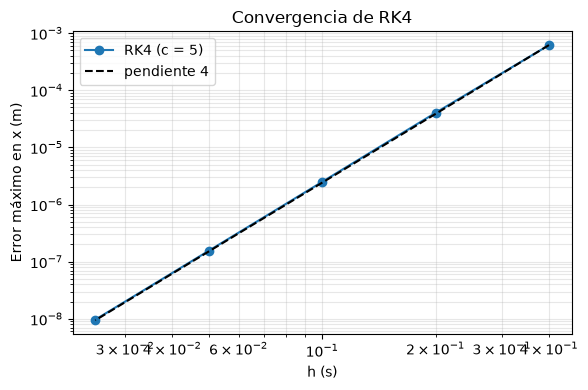

In [6]:
pasos = [0.4, 0.2, 0.1, 0.05, 0.025]
errores = []
for hh in pasos:
    t, Y = rk4(f_masa_resorte, (t0, tf), y0, hh, args=(5.0,))
    errores.append(np.max(np.abs(Y[:, 0] - x_exacta(t, 5.0))))

print(f"{'h (s)':>7} {'error máx':>11} {'razón':>7} {'orden p':>8}")
for i, (hh, e) in enumerate(zip(pasos, errores)):
    if i == 0:
        print(f"{hh:7.3f} {e:11.3e}")
    else:
        print(f"{hh:7.3f} {e:11.3e} {errores[i-1]/e:7.2f} {np.log2(errores[i-1]/e):8.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(pasos, errores, "o-", label="RK4 (c = 5)")
ax.loglog(pasos, errores[0] * (np.array(pasos) / pasos[0])**4, "k--", label="pendiente 4")
ax.set(xlabel="h (s)", ylabel="Error máximo en x (m)", title="Convergencia de RK4")
ax.grid(alpha=0.3, which="both"); ax.legend()
fig.tight_layout(); plt.show()